### Rotina para baixar dados disponíveis na API da estação de referência (OpenAQ)

In [1]:
import requests
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt

from dotenv import load_dotenv
import os

In [2]:
load_dotenv()

API_KEY = os.getenv("OPENAQ_API_KEY")

headers = {
    "X-API-Key": API_KEY
}

BASE_URL = "https://api.openaq.org/v3"

In [3]:
# informações do ponto
lat = -23.6473149
lon = -46.6643635

date_from="2026-05-27T00:00:00Z"
date_to="2026-06-26T00:00:00Z"

In [4]:
url = f"{BASE_URL}/locations"

params = {
    "coordinates": f"{lat},{lon}",
    "radius": 5000,      # 5 km
    "limit": 100,
    "page": 1
}

r = requests.get(url, headers=headers, params=params)
r.raise_for_status()

data = r.json()
locations = pd.json_normalize(data["results"])

locations[[
    "id", "name", "coordinates.latitude", "coordinates.longitude",
    "datetimeFirst.utc", "datetimeLast.utc"
]].head()

,id,name,coordinates.latitude,coordinates.longitude,datetimeFirst.utc,datetimeLast.utc
0,5252,Congonhas,-23.616320,-46.663466,2017-08-10T23:00:00Z,2023-04-05T20:00:00Z
1,5278,Interlagos,-23.680508,-46.675043,2017-07-01T00:00:00Z,2023-04-05T20:00:00Z
2,5301,Santo Amaro,-23.654977,-46.709998,2017-07-01T00:00:00Z,2023-04-05T20:00:00Z
3,589967,Sao Paulo,-23.629158,-46.696558,2023-02-14T02:00:00Z,2025-03-04T12:00:00Z
4,6139516,São Paulo,-23.647315,-46.664364,2025-11-22T22:00:00Z,2026-06-26T22:00:00Z


In [5]:
location_id = 6139516

url = f"{BASE_URL}/locations/{location_id}/sensors"

r = requests.get(url, headers=headers)
r.raise_for_status()

sensors = pd.json_normalize(r.json()["results"])

sensors[[
    "id",
    "name",
    "parameter.name",
    "parameter.displayName",
    "parameter.units"
]]

,id,name,parameter.name,parameter.displayName,parameter.units
0,14700784,pm1 µg/m³,pm1,PM1,µg/m³
1,14700785,pm25 µg/m³,pm25,PM2.5,µg/m³
2,14700786,relativehumidity %,relativehumidity,RH,%
3,14700787,temperature c,temperature,Temperature (C),c
4,14700788,um003 particles/cm³,um003,PM0.3 count,particles/cm³


In [6]:
def baixa_sensor(sensor_id, date_from, date_to, api_key):

    headers = {
        "X-API-Key": api_key
    }

    base_url = f"https://api.openaq.org/v3/sensors/{sensor_id}/hours"

    page = 1
    limit = 1000

    dados = []

    while True:

        params = {
            "datetime_from": date_from,
            "datetime_to": date_to,
            "limit": limit,
            "page": page
        }

        r = requests.get(base_url, headers=headers, params=params)
        r.raise_for_status()

        js = r.json()

        results = js.get("results", [])

        if len(results) == 0:
            break

        dados.extend(results)

        found = js.get("meta", {}).get("found", 0)

        if page * limit >= found:
            break

        page += 1

    df = pd.json_normalize(dados)

    return df

In [7]:
dfs = {}

for _, row in sensors.iterrows():

    sensor_id = row["id"]
    nome = row["parameter.name"]

    print(f"Baixando: {nome}")

    try:

        df_tmp = baixa_sensor(
            sensor_id=sensor_id,
            date_from=date_from,
            date_to=date_to,
            api_key=API_KEY
        )

        dfs[nome] = df_tmp

    except Exception as e:

        print(f"Erro em {nome}: {e}")

Baixando: pm1
Baixando: pm25
Baixando: relativehumidity
Baixando: temperature
Baixando: um003


In [8]:
# ORGANIZA TODAS AS SÉRIES

serie_final = pd.DataFrame()

for nome, df_tmp in dfs.items():

    if len(df_tmp) == 0:
        continue

    df_aux = pd.DataFrame()


    df_aux["time"] = pd.to_datetime(
        df_tmp["period.datetimeFrom.local"]
    )


    df_aux[nome] = df_tmp["value"]


    df_aux = df_aux.set_index("time")


    df_aux = df_aux[~df_aux.index.duplicated(keep="first")]


    if serie_final.empty:

        serie_final = df_aux

    else:

        serie_final = serie_final.join(
            df_aux,
            how="outer"
        )

In [ ]:
# ORDENA PELO TEMPO
serie_final = serie_final.sort_index()

date_str = pd.to_datetime(date_to).strftime("%d%m%y")
# SALVA CSV
arquivo_saida = f"../data/operational/openaq_location_6139516_{date_str}.csv"

serie_final.to_csv(
   arquivo_saida,
   sep=",",
   decimal=".",
   encoding="utf-8"
)

print(f"Arquivo salvo: {arquivo_saida}")


Arquivo salvo: ../data/operacao/openaq_location_6139516_260626.csv


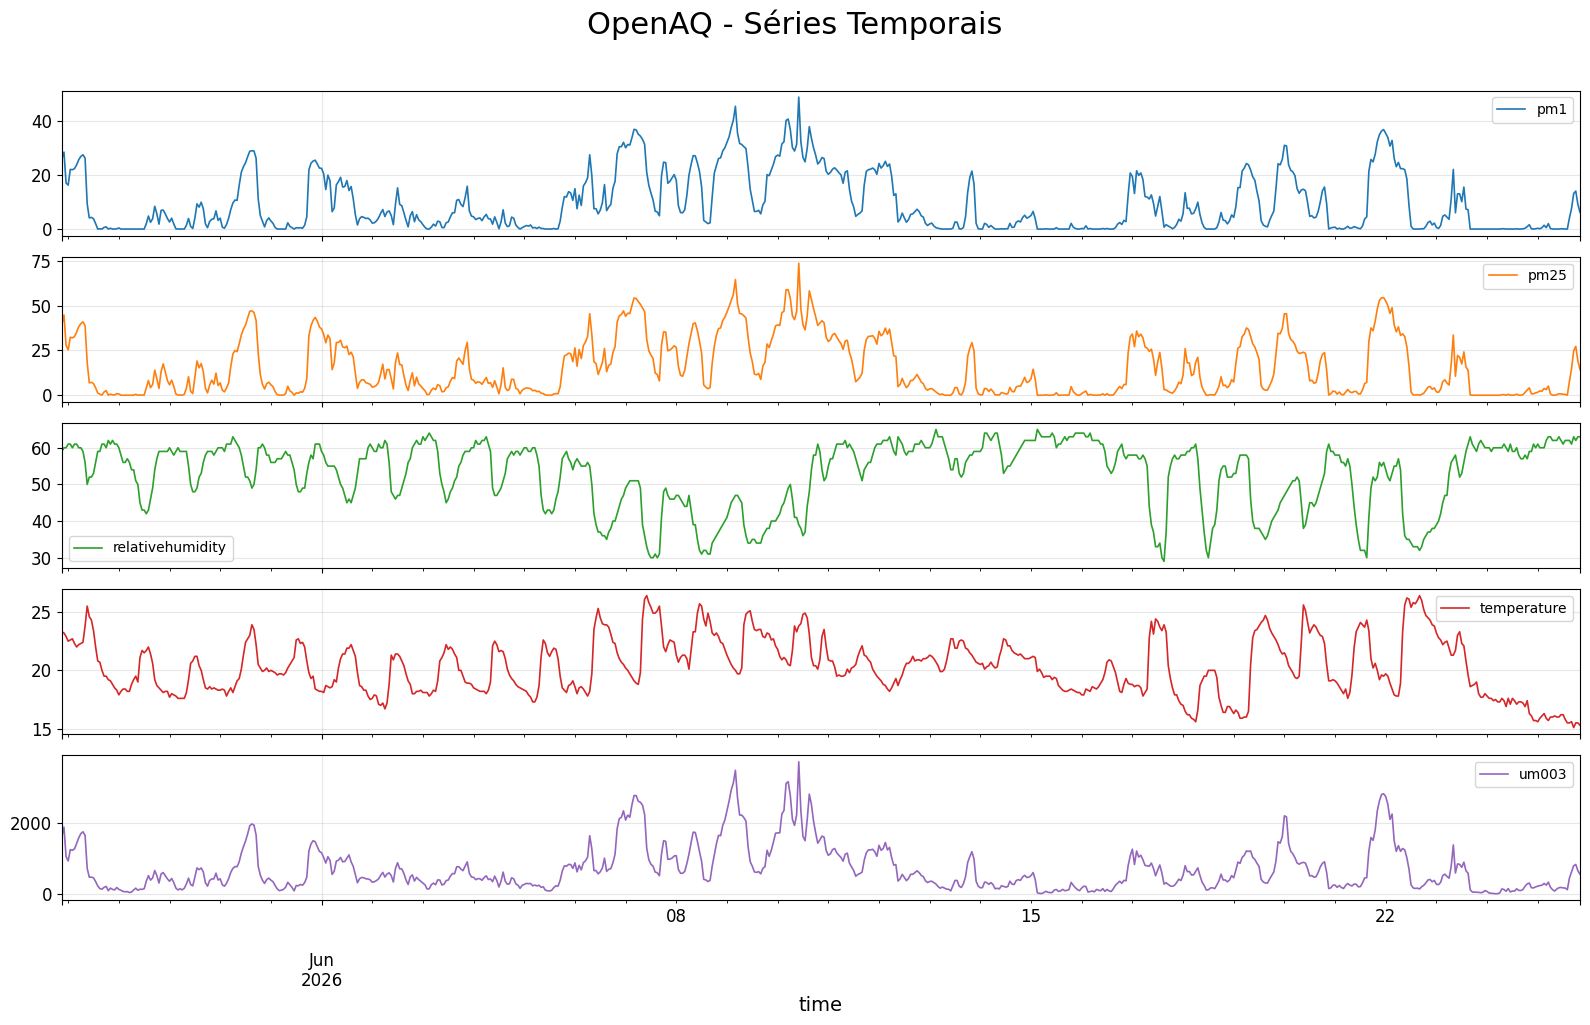

In [10]:
axes = serie_final.plot(
    figsize=(16,10),
    subplots=True,
    sharex=True,
    linewidth=1.2,
    fontsize=12
)


plt.suptitle(
    "OpenAQ - Séries Temporais",
    fontsize=22,
    y=1.02
)


for ax in axes:


    ax.set_title(
        ax.get_title(),
        fontsize=16
    )


    ax.set_ylabel(
        ax.get_ylabel(),
        fontsize=14
    )

    ax.set_xlabel(
        ax.get_xlabel(),
        fontsize=14
    )


    ax.tick_params(
        axis='both',
        labelsize=12
    )

    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()